In [244]:
import pandas as pd
import numpy as np

In [245]:
X = pd.read_csv(r"C:\Users\njourdan\Downloads\Voitures.csv",delimiter=";", index_col=0)

X

,puissance,Longueur,Hauteur,poids,CO2,Origine,Carburant,4X4
Modele,,,,,,,,
Alfasud TI,75,421,149,1217,143,Europe,Diesel,non
Audi 100,138,426,146,1381,142,France,Diesel,non
Simca 1300,204,491,145,1723,223,France,Diesel,non
Citroen GS Club,150,486,158,1735,188,France,Diesel,non
Fiat 132,61,367,147,932,141,France,Essence,non
Lancia Beta,340,502,148,1835,291,Autre,Essence,non
Peugeot 504,102,421,143,1205,168,Europe,Essence,non
Renault 16 TL,202,455,167,1595,237,Autre,Diesel,oui
Renault 30,223,429,154,1595,235,Autre,Essence,non


In [246]:
X.dtypes
# 10 individus et 8variables

# 3 variables sont catégorielles

# On va séparer les variables numériques (X1) et catégorielles (X2)

puissance     int64
Longueur      int64
Hauteur       int64
poids         int64
CO2           int64
Origine      object
Carburant    object
4X4          object
dtype: object

In [247]:
X=X.rename(columns={"4X4":"quatre"})
X

import numpy as np

X1 = X.select_dtypes(exclude=['object'])

X2 = X.select_dtypes(include=[object])

X1.head()


,puissance,Longueur,Hauteur,poids,CO2
Modele,,,,,
Alfasud TI,75,421,149,1217,143
Audi 100,138,426,146,1381,142
Simca 1300,204,491,145,1723,223
Citroen GS Club,150,486,158,1735,188
Fiat 132,61,367,147,932,141


<function matplotlib.pyplot.show(close=None, block=None)>

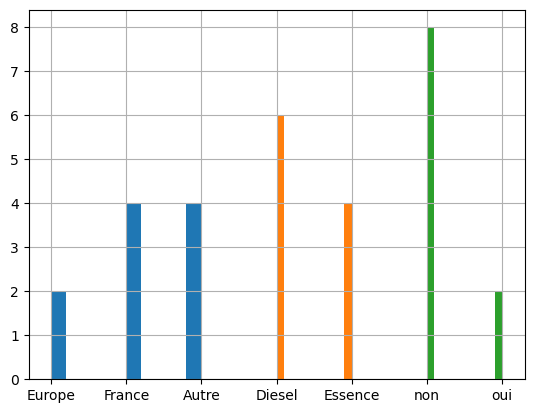

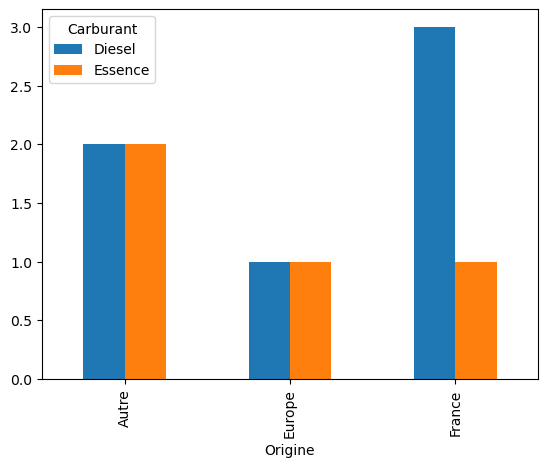

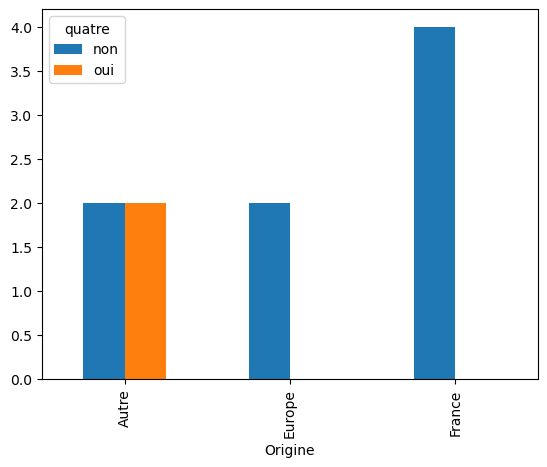

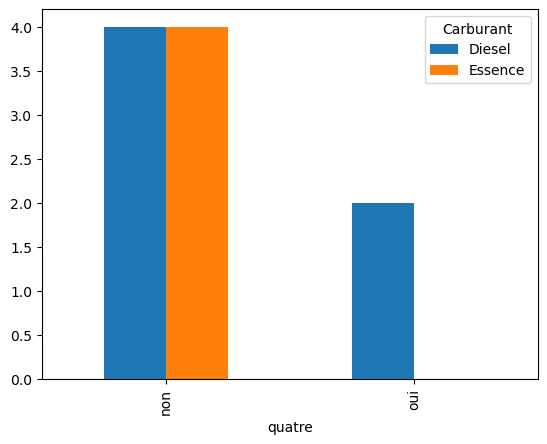

In [248]:
#On regarde un peu les modalités des variables catégorielles

import seaborn as sns

import matplotlib.pyplot as plt

X2.Origine.hist(bins=10)
X2.Carburant.hist(bins=10)
X2.quatre.hist(bins=10)

pd.crosstab(X2.Origine,X2.Carburant).plot(kind="bar") ; plt.show
pd.crosstab(X2.Origine,X2.quatre).plot(kind="bar") ; plt.show
pd.crosstab(X2.quatre,X2.Carburant).plot(kind="bar") ; plt.show


In [249]:
# On voit bien les biais initiaux des variables catégorielles...
# Toutes les voitures 4X4 sont au diesel et non europeenne
# Le diesel est sur-représenté en France
 

# On va transformer les variables catégorielles en variables binaires 

# Vérification avant qu'il n'y a aucune donnée manquante

In [250]:
X1.isnull().sum()


puissance    0
Longueur     0
Hauteur      0
poids        0
CO2          0
dtype: int64

In [251]:
X2bis=pd.get_dummies(X2)
# drop_first=True permet de ne garder qu'une variable binaire plutôt que 2 identiques
X2bis.head()

,Origine_Autre,Origine_Europe,Origine_France,Carburant_Diesel,Carburant_Essence,quatre_non,quatre_oui
Modele,,,,,,,
Alfasud TI,0,1,0,1,0,1,0
Audi 100,0,0,1,1,0,1,0
Simca 1300,0,0,1,1,0,1,0
Citroen GS Club,0,0,1,1,0,1,0
Fiat 132,0,0,1,0,1,1,0


In [252]:
# Oncalcule "à la main" les podérations de chaque modalités afin d'obtenir des données normalisées

In [253]:
import numpy 
n=X2bis.shape[0]
print(n)
X2ter2=(numpy.sum(X2bis,axis=0))/n
print(X2ter2)
X2ter2=numpy.square(X2ter2)
X2ter=X2bis/X2ter2
X2ter.head()

10
Origine_Autre        0.4
Origine_Europe       0.2
Origine_France       0.4
Carburant_Diesel     0.6
Carburant_Essence    0.4
quatre_non           0.8
quatre_oui           0.2
dtype: float64


,Origine_Autre,Origine_Europe,Origine_France,Carburant_Diesel,Carburant_Essence,quatre_non,quatre_oui
Modele,,,,,,,
Alfasud TI,0.0,25.0,0.00,2.777778,0.00,1.5625,0.0
Audi 100,0.0,0.0,6.25,2.777778,0.00,1.5625,0.0
Simca 1300,0.0,0.0,6.25,2.777778,0.00,1.5625,0.0
Citroen GS Club,0.0,0.0,6.25,2.777778,0.00,1.5625,0.0
Fiat 132,0.0,0.0,6.25,0.000000,6.25,1.5625,0.0


In [254]:
# Les données sont maintenant prêtes pour l'analyse. Les valeurs tiennent compte de la sur ou sous représentation de la modalité.
#Les modalités faiblement représentées sont "tirées". Comme les "outliers" des données continues, elles vont "tirer" les axes factoriels.


# On regarde maintenant les données continues: corrélations et distributions

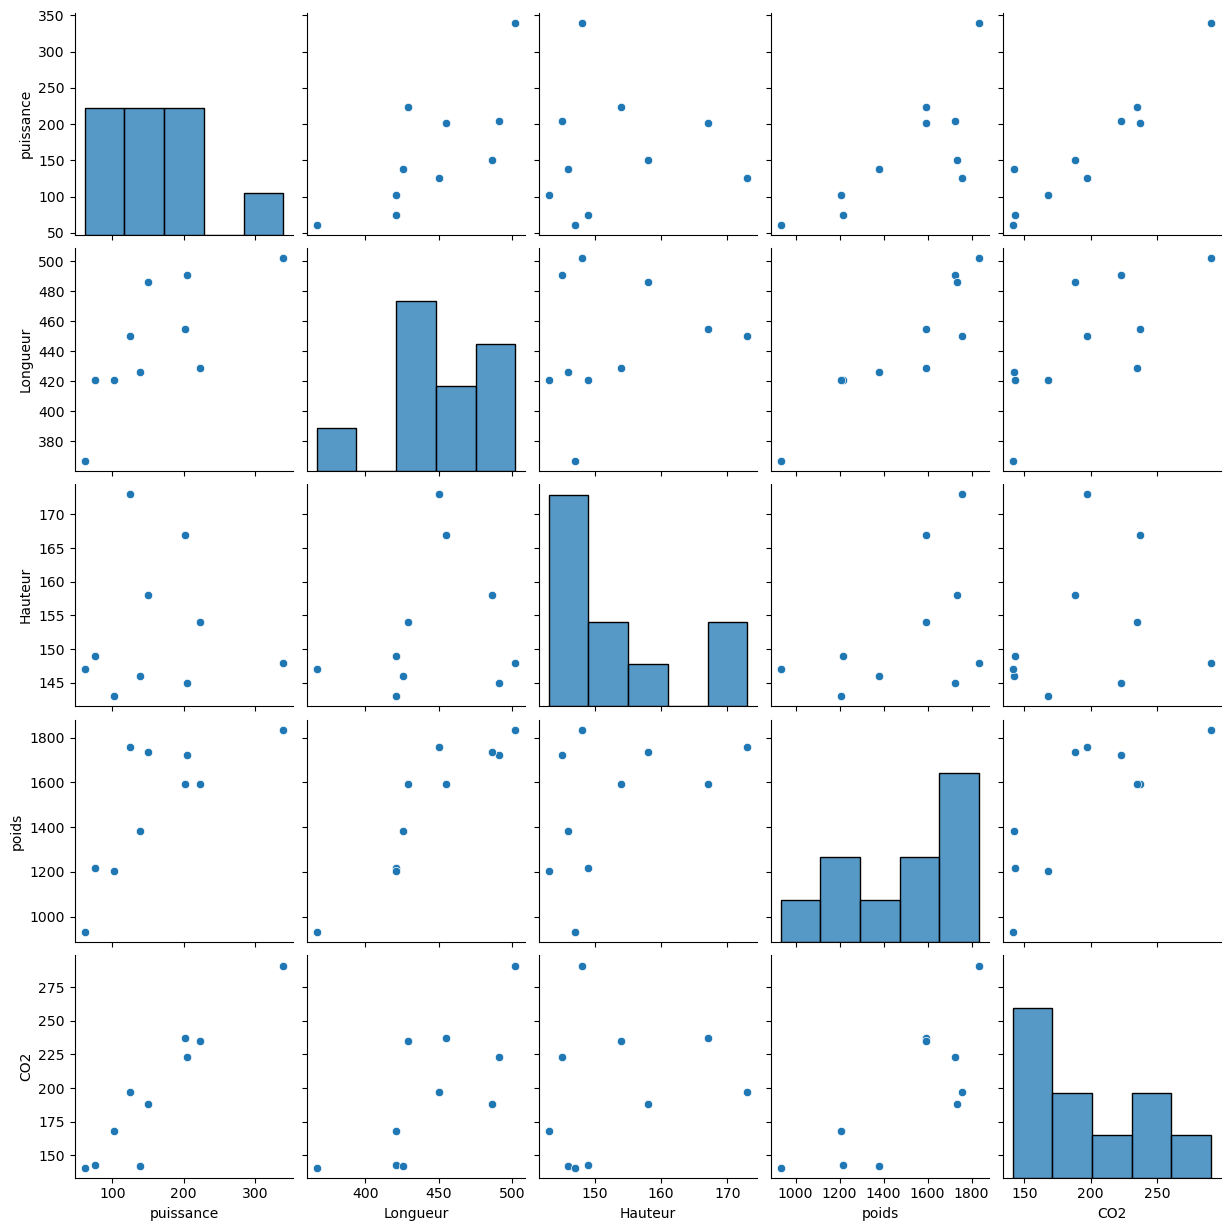

In [255]:
import seaborn as sns
sns.pairplot(X1)

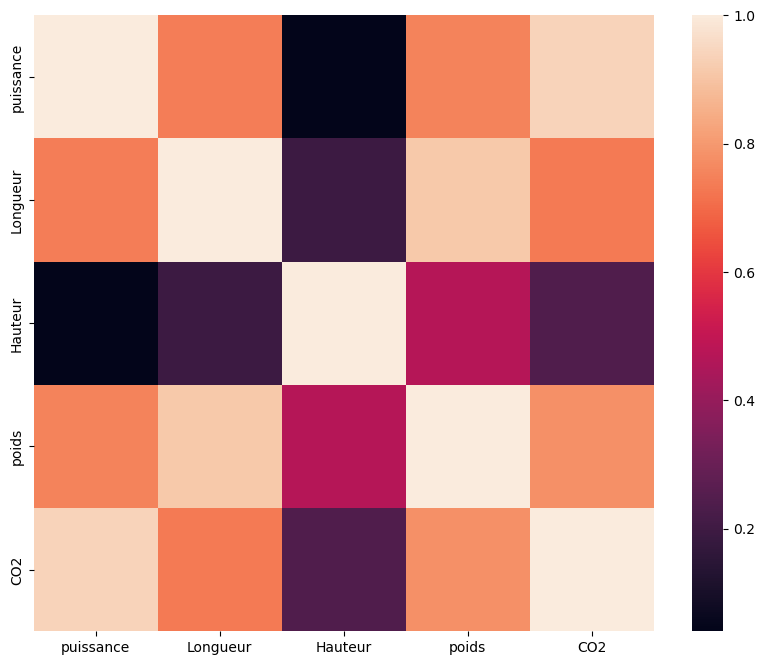

In [256]:
import matplotlib.pyplot as plt


corr=X1.corr()
corr=corr.round(2)
f,ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr)

plt.show()

In [257]:
# On va centrer/réduire. Intéressant de comparer dans le futur avec une transformation "RobustScaler"

In [258]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Z = StandardScaler().fit_transform(X1)
Z1 = pd.DataFrame(data = Z, columns = X1.columns)
Z1.head()

,puissance,Longueur,Hauteur,poids,CO2
0,-1.102875,-0.614031,-0.418854,-0.988562,-1.126565
1,-0.304241,-0.485033,-0.732994,-0.410579,-1.147623
2,0.532422,1.191942,-0.837708,0.794727,0.558018
3,-0.152121,1.062944,0.523567,0.837018,-0.178987
4,-1.280349,-2.007209,-0.628281,-1.992984,-1.168680


In [259]:
Z1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   puissance  10 non-null     float64
 1   Longueur   10 non-null     float64
 2   Hauteur    10 non-null     float64
 3   poids      10 non-null     float64
 4   CO2        10 non-null     float64
dtypes: float64(5)
memory usage: 528.0 bytes


In [260]:
# Intéressant de faire 3 études: ACP avec les données continues initiales. ACM avec les données catégorielles. AFDM avec les données complètes.
#On regarde le dernier cas ici

In [273]:
X2ter=X2ter.reset_index(drop=True)

X4=Z1.join(X2ter)
X4["Modele"]= X.index
X4.index=X4.Modele
X4.drop (X4.columns [-1], axis = 1, inplace = True)
#X=pd.DataFrame(X)
X4.head()

,puissance,Longueur,Hauteur,poids,CO2,Origine_Autre,Origine_Europe,Origine_France,Carburant_Diesel,Carburant_Essence,quatre_non,quatre_oui
Modele,,,,,,,,,,,,
Alfasud TI,-1.102875,-0.614031,-0.418854,-0.988562,-1.126565,0.0,25.0,0.00,2.777778,0.00,1.5625,0.0
Audi 100,-0.304241,-0.485033,-0.732994,-0.410579,-1.147623,0.0,0.0,6.25,2.777778,0.00,1.5625,0.0
Simca 1300,0.532422,1.191942,-0.837708,0.794727,0.558018,0.0,0.0,6.25,2.777778,0.00,1.5625,0.0
Citroen GS Club,-0.152121,1.062944,0.523567,0.837018,-0.178987,0.0,0.0,6.25,2.777778,0.00,1.5625,0.0
Fiat 132,-1.280349,-2.007209,-0.628281,-1.992984,-1.168680,0.0,0.0,6.25,0.000000,6.25,1.5625,0.0


In [274]:
import sklearn as sk

In [275]:
from sklearn.decomposition import PCA

In [276]:
print(PCA)

<class 'sklearn.decomposition._pca.PCA'>


In [277]:
acp=PCA(svd_solver='full')
print(acp)

PCA(svd_solver='full')


In [278]:
coord1=acp.fit_transform(X4)

In [279]:
print(coord1)

[[-1.71493086e+01  1.19458291e+01 -2.45923049e+00 -2.11777526e+00
   1.30637671e+00 -1.45084525e-01 -1.79601198e-01  7.18251922e-03
   5.52571348e-02  2.42264247e-16]
 [-6.17608648e-01 -7.61881145e+00 -4.52243720e+00 -6.39104688e-02
   9.55730575e-01 -5.46655983e-01  3.56435127e-01 -1.43196420e-01
  -3.71695380e-02  2.42264247e-16]
 [-4.42705619e-01 -7.73680174e+00 -4.09430173e+00 -1.61959673e+00
  -1.26192638e+00 -3.73761469e-01  1.09202598e-02  2.65895637e-01
   1.36571876e-02  2.42264247e-16]
 [-3.92612543e-01 -7.63543516e+00 -4.30744711e+00 -1.30885234e+00
  -4.92314607e-01  1.01807987e+00 -1.91836759e-01 -1.28828441e-01
  -3.16856648e-02  2.42264247e-16]
 [-1.41824826e+00 -8.07648301e+00 -1.78685061e-01  5.58749638e+00
   3.40334219e-01 -8.67074410e-02 -1.78106874e-01  5.97062539e-03
   5.47499560e-02  2.42264247e-16]
 [ 2.41079958e-01 -6.50435707e+00  7.19803779e+00 -2.26524908e+00
  -8.75499298e-01 -2.55570734e-01  2.70803626e-02 -1.51150153e-01
   7.22671952e-02  2.42264247e-16

In [280]:
print(acp.explained_variance_ratio_)

[5.60069514e-01 3.43413249e-01 6.99458662e-02 2.13138422e-02
 3.97421382e-03 1.02708197e-03 1.75073319e-04 6.87405715e-05
 1.24195956e-05 2.49363107e-34]


In [281]:
# On a 90% de la variance expliquée sur 2 axes

In [282]:
# Les Valeurs propres
eigval = acp.explained_variance_
print([eigval])

[array([1.46469054e+02, 8.98092332e+01, 1.82922023e+01, 5.57398363e+00,
       1.03933409e+00, 2.68601880e-01, 4.57850725e-02, 1.79769943e-02,
       3.24796542e-03, 6.52132949e-32])]


In [283]:
#On a les 4 premières VP >1 

#On va regarder l'évolution des VP en fonction des composantes principales

12
[ 0  1  2  3  4  5  6  7  8  9 10 11]
[1.46469054e+02 8.98092332e+01 1.82922023e+01 5.57398363e+00
 1.03933409e+00 2.68601880e-01 4.57850725e-02 1.79769943e-02
 3.24796542e-03 6.52132949e-32]


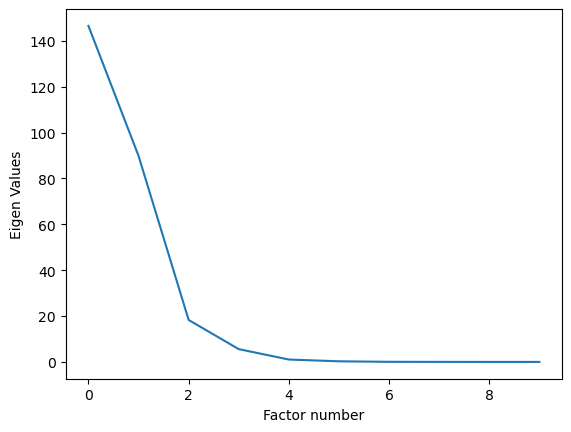

In [284]:
#nombre de variables
p = X4.shape[1]
print(p)
nunu=np.arange(p)
print(nunu)
print(eigval)
#nombre d'observations
n = X4.shape[0]
#matrice des X
X = X4.values

import matplotlib.pyplot as plt
plt.plot(np.arange(10),eigval)
plt.ylabel("Eigen Values")
plt.xlabel("Factor number")
plt.show()

In [285]:
# 4 composantes expliquent la variance totalement sans bruit de fond. Il est probable que ce soient les variables catégorielles qui différencient tous les modèles. Biaisées dans le dataset. 

#On va regarder sur 2 CP (90% déjà de variance expliquée) 

acp=PCA(n_components=2,svd_solver='full')
coord=acp.fit_transform(X4)
print(coord)

[[-17.14930856  11.9458291 ]
 [ -0.61760865  -7.61881145]
 [ -0.44270562  -7.73680174]
 [ -0.39261254  -7.63543516]
 [ -1.41824826  -8.07648301]
 [  0.24107996  -6.50435707]
 [-17.83788256  11.3412298 ]
 [ 18.74452838  10.28075263]
 [  0.11748187  -6.34979022]
 [ 18.75527598  10.35386712]]


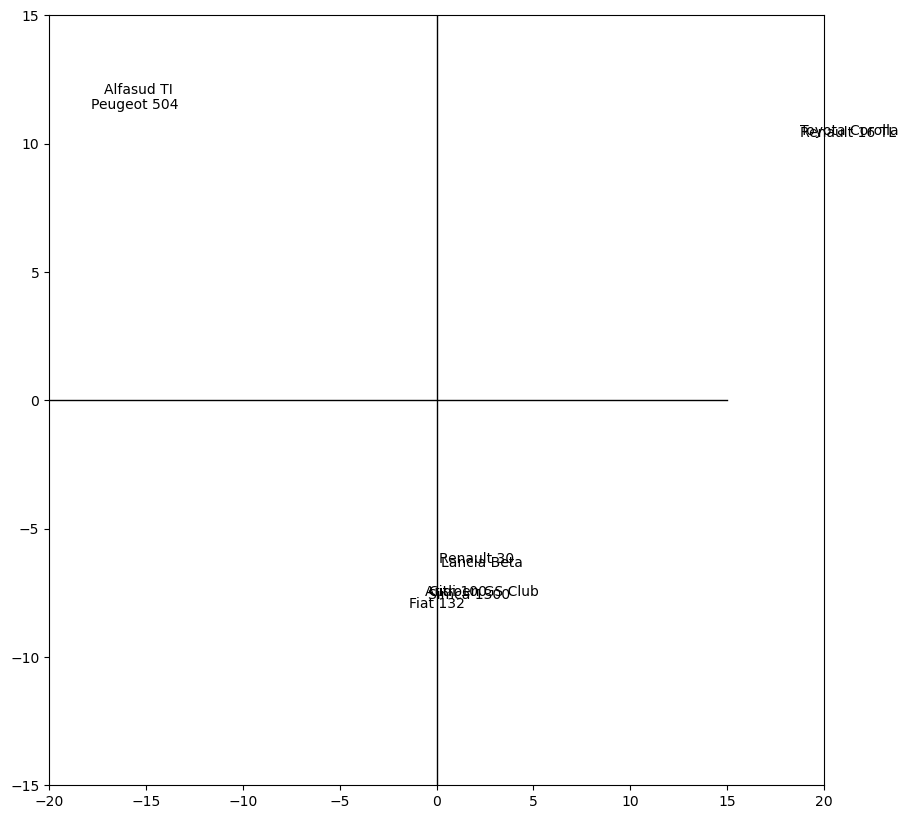

In [286]:
f,ax = plt.subplots(figsize=(10,10))
#fig, axes = plt.plot(figsize=(10,10))
ax.set_xlim(-20,20)
ax.set_ylim(-15,15)
n = X4.shape[0]
for i in range(n):
    plt.annotate(X4.index[i],(coord[i,0],coord[i,1]))
plt.plot([-20,15],[0,0],color='black',linestyle='-',linewidth=1)
plt.plot([0,0],[-20,15],color='black',linestyle='-',linewidth=1)
plt.show()

In [310]:
#Quelles sont les variables qui distinguent ces voitures?
#Comment projeter de nouvelles voitures?

#Package "prince"

In [329]:
#On peut reprendre les données initiales normalisées de l'acp 

X4_transform = acp.transform(X4)
#X4_transform

X_projected = acp.inverse_transform(X4_transform)
#X_projected



In [328]:
loadings = acp.components_.T * np.sqrt(acp.explained_variance_)

loading_matrix = pd.DataFrame(loadings, columns=['PC1', 'PC2'])
#loading_matrix
